In [1]:
# Import necessary libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Configuration to display graphs in the notebook
%matplotlib inline
plt.style.use('ggplot')
sns.set(style='whitegrid')


# <b><span style='color:#F1A424'>|</span> Data Loading and Initial Exploration <span style='color:#F1A424'>|</span></b>
Load your dataset and get a first look at its structure and contents.


In [2]:
# Load the dataset
df = pd.read_csv('Datasets/Tabular/Time_series/csv/dataset_time_series.csv')

# Display basic information
print("Table shape:", df.shape)
print("Column names:", df.columns.tolist())
df.head()


Table shape: (9990, 13)
Column names: ['Unnamed: 0', 'ID', 'Feature_1', 'Feature_2', 'Feature_3', 'Feature_4', 'Feature_5', 'Feature_6', 'Feature_7', 'Feature_8', 'Feature_9', 'Feature_10', 'Target']


,Unnamed: 0,ID,Feature_1,Feature_2,Feature_3,Feature_4,Feature_5,Feature_6,Feature_7,Feature_8,Feature_9,Feature_10,Target
0,10,11,-0.221708,1.133047,1.352241,-0.124647,4.017140,1.836551,-0.478149,2.074969,2.129173,-0.232051,2.304265
1,11,12,-0.221864,1.196557,1.308560,-0.850371,4.322888,2.102496,-0.969116,-2.437057,1.455233,0.441201,0.452407
2,12,13,0.132982,0.630783,0.991719,-0.564366,3.008537,2.650296,0.899033,-4.669752,1.825879,-0.501489,2.858446
3,13,14,-0.943639,0.969822,0.903074,-0.188469,2.034749,2.821024,0.170669,-4.823012,1.980669,-0.103675,2.468120
4,14,15,-0.848458,1.440260,1.624604,-1.532611,0.911643,2.157261,-0.214645,-0.074111,2.073125,0.239503,2.280645


# <b><span style='color:#F1A424'>|</span> Categorical Data Encoding <span style='color:#F1A424'>|</span></b>
Convert categorical variables into numeric codes for analysis.


In [3]:
# Transform categorical columns to numerical
from sklearn.preprocessing import LabelEncoder
label_encoders = {}
for col in df.select_dtypes(include=['object', 'category']).columns:
    le = LabelEncoder()
    df[col] = le.fit_transform(df[col])
    label_encoders[col] = le
print("\nDataFrame after categorical encoding:")
df.head()



DataFrame after categorical encoding:


,Unnamed: 0,ID,Feature_1,Feature_2,Feature_3,Feature_4,Feature_5,Feature_6,Feature_7,Feature_8,Feature_9,Feature_10,Target
0,10,11,-0.221708,1.133047,1.352241,-0.124647,4.017140,1.836551,-0.478149,2.074969,2.129173,-0.232051,2.304265
1,11,12,-0.221864,1.196557,1.308560,-0.850371,4.322888,2.102496,-0.969116,-2.437057,1.455233,0.441201,0.452407
2,12,13,0.132982,0.630783,0.991719,-0.564366,3.008537,2.650296,0.899033,-4.669752,1.825879,-0.501489,2.858446
3,13,14,-0.943639,0.969822,0.903074,-0.188469,2.034749,2.821024,0.170669,-4.823012,1.980669,-0.103675,2.468120
4,14,15,-0.848458,1.440260,1.624604,-1.532611,0.911643,2.157261,-0.214645,-0.074111,2.073125,0.239503,2.280645


# <b><span style='color:#F1A424'>|</span> Correlation Analysis <span style='color:#F1A424'>|</span></b>
Analyze the relationships between features to inform feature selection.
We are using the absolute value of the correlation matrix to get insight on the magnitude of the correlation between the features, as the sign of the correlation is not important for the feature selection step.


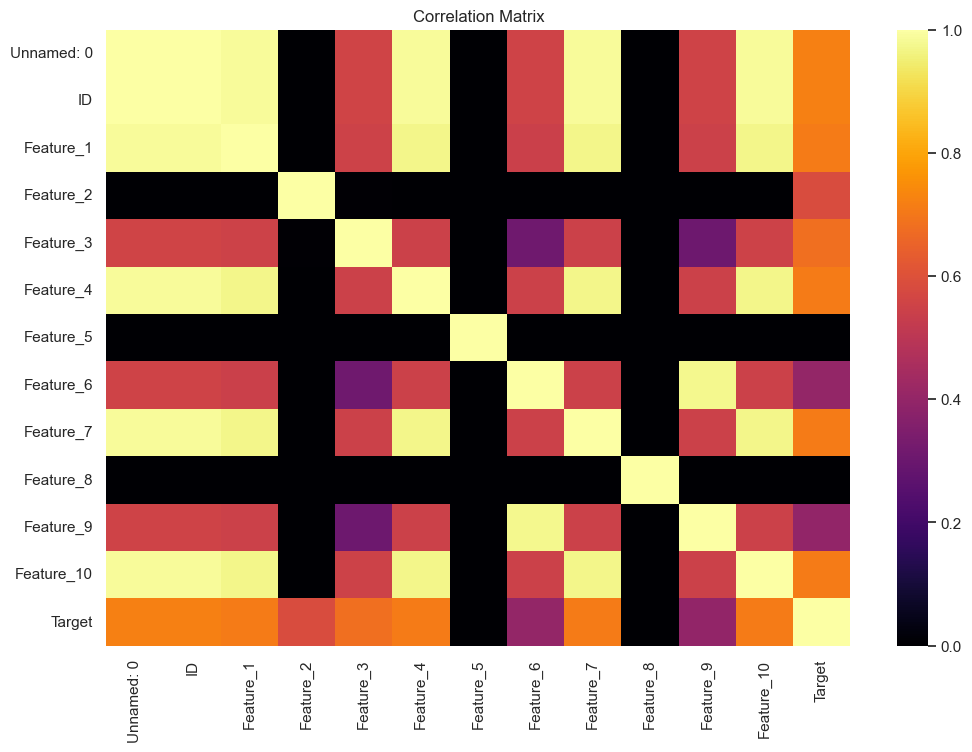

In [4]:
# Display correlation matrix
corr_matrix = df.corr().abs()
plt.figure(figsize=(12, 8))
sns.heatmap(corr_matrix, cmap='inferno', vmin=0, vmax=1)
plt.title('Correlation Matrix')
plt.show()


In [5]:
# Import necessary libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import torch
import torch.nn as nn
import torch.optim as optim
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error
from torch.utils.data import TensorDataset, DataLoader


# <b><span style='color:#F1A424'>|</span> Time Series Preprocessing <span style='color:#F1A424'>|</span></b>
Preprocessing of time series data: splitting, normalization, and extraction of features and target.


In [6]:
# Check for any missing values
print(f"Missing values in dataset: {df.isna().sum().sum()}")

# Split into features and target
X = df.drop(columns=['Target'])
y = df['Target']

# Scale features
scaler_X = StandardScaler()
X_scaled = scaler_X.fit_transform(X)

# Scale target
y_mean = y.mean()
y_std = y.std()
print(f"Target statistics - Mean: {y_mean:.4f}, Std: {y_std:.4f}")
y_scaled = (y - y_mean) / y_std


Missing values in dataset: 0
Target statistics - Mean: 19.6674, Std: 15.5944


# <b><span style='color:#F1A424'>|</span> Sequence Creation <span style='color:#F1A424'>|</span></b>
Creating sequences for sequential learning (LSTM).


In [7]:
def create_sequences(X, y, seq_length):
    xs, ys = [], []
    for i in range(len(X) - seq_length):
        xs.append(X[i:i+seq_length])
        ys.append(y[i+seq_length])
    return np.array(xs), np.array(ys)

# Create sequences
seq_length = 10
X_seq, y_seq = create_sequences(X_scaled, y_scaled, seq_length)
print(f"Sequence shapes: X = {X_seq.shape}, y = {y_seq.shape}")

# Split into training and test sets
train_size = int(len(X_seq) * 0.8)
X_train, X_test = X_seq[:train_size], X_seq[train_size:]
y_train, y_test = y_seq[:train_size], y_seq[train_size:]

# Convert to PyTorch tensors
X_train_tensor = torch.FloatTensor(X_train)
y_train_tensor = torch.FloatTensor(y_train).reshape(-1, 1)
X_test_tensor = torch.FloatTensor(X_test)
y_test_tensor = torch.FloatTensor(y_test).reshape(-1, 1)

print(f"Training data: X = {X_train_tensor.shape}, y = {y_train_tensor.shape}")
print(f"Test data: X = {X_test_tensor.shape}, y = {y_test_tensor.shape}")


Sequence shapes: X = (9980, 10, 12), y = (9980,)
Training data: X = torch.Size([7984, 10, 12]), y = torch.Size([7984, 1])
Test data: X = torch.Size([1996, 10, 12]), y = torch.Size([1996, 1])


# <b><span style='color:#F1A424'>|</span> LSTM Model Architecture <span style='color:#F1A424'>|</span></b>
Definition of the LSTM model architecture for time series forecasting.


In [8]:
class LSTMModel(nn.Module):
    def __init__(self, input_size, hidden_size, num_layers=2, dropout=0.2):
        super(LSTMModel, self).__init__()
        self.hidden_size = hidden_size
        self.num_layers = num_layers
        
        self.lstm = nn.LSTM(
            input_size=input_size,
            hidden_size=hidden_size,
            num_layers=num_layers,
            batch_first=True,
            dropout=dropout
        )
        
        self.fc1 = nn.Linear(hidden_size, hidden_size // 2)
        self.relu = nn.ReLU()
        self.dropout = nn.Dropout(dropout)
        self.fc2 = nn.Linear(hidden_size // 2, 1)
        
    def forward(self, x):
        batch_size = x.size(0)
        h0 = torch.zeros(self.num_layers, batch_size, self.hidden_size).to(x.device)
        c0 = torch.zeros(self.num_layers, batch_size, self.hidden_size).to(x.device)
        
        lstm_out, _ = self.lstm(x, (h0, c0))
        
        out = self.fc1(lstm_out[:, -1, :])
        out = self.relu(out)
        out = self.dropout(out)
        out = self.fc2(out)
        
        return out


# <b><span style='color:#F1A424'>|</span> LSTM Training Setup <span style='color:#F1A424'>|</span></b>
LSTM model configuration, loss, optimizer, and DataLoader setup.


In [9]:
# Model configuration
input_size = X_train.shape[2]
hidden_size = 128
num_layers = 2
dropout = 0.2

# Create model and training components
model = LSTMModel(input_size, hidden_size, num_layers, dropout)
criterion = nn.MSELoss()
optimizer = optim.Adam(model.parameters(), lr=0.001, weight_decay=1e-5)
scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer, 'min', factor=0.5, patience=5)

# Create DataLoader
batch_size = 64
train_dataset = TensorDataset(X_train_tensor, y_train_tensor)
train_loader = DataLoader(dataset=train_dataset, batch_size=batch_size, shuffle=True)


# <b><span style='color:#F1A424'>|</span> Training Loop <span style='color:#F1A424'>|</span></b>
Training loop with early stopping and saving the best model.


In [10]:
# Training parameters
num_epochs = 200
patience = 15
best_loss = float('inf')
counter = 0
train_losses = []
val_losses = []

# Training loop
for epoch in range(num_epochs):
    model.train()
    epoch_loss = 0
    
    for batch_X, batch_y in train_loader:
        outputs = model(batch_X)
        loss = criterion(outputs, batch_y)
        
        optimizer.zero_grad()
        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
        optimizer.step()
        
        epoch_loss += loss.item()
    
    avg_train_loss = epoch_loss / len(train_loader)
    train_losses.append(avg_train_loss)
    
    # Validation
    model.eval()
    with torch.no_grad():
        val_outputs = model(X_test_tensor)
        val_loss = criterion(val_outputs, y_test_tensor)
        val_losses.append(val_loss.item())
        
        scheduler.step(val_loss)
        
        if val_loss < best_loss:
            best_loss = val_loss
            counter = 0
            torch.save(model.state_dict(), 'best_lstm_model.pth')
        else:
            counter += 1
    
    if counter >= patience:
        print(f'Early stopping triggered at epoch {epoch+1}')
        break
    
    if (epoch+1) % 10 == 0:
        print(f'Epoch [{epoch+1}/{num_epochs}], Train Loss: {avg_train_loss:.4f}, Val Loss: {val_loss.item():.4f}')

# Load best model
model.load_state_dict(torch.load('best_lstm_model.pth'))


Epoch [10/200], Train Loss: 0.0163, Val Loss: 0.0163


Epoch [20/200], Train Loss: 0.0132, Val Loss: 0.0164


Epoch [30/200], Train Loss: 0.0132, Val Loss: 0.0103


Epoch [40/200], Train Loss: 0.0126, Val Loss: 0.0099


Epoch [50/200], Train Loss: 0.0126, Val Loss: 0.0089


Epoch [60/200], Train Loss: 0.0124, Val Loss: 0.0078


Epoch [70/200], Train Loss: 0.0121, Val Loss: 0.0077


Early stopping triggered at epoch 80


<All keys matched successfully>

# <b><span style='color:#F1A424'>|</span> Model Evaluation <span style='color:#F1A424'>|</span></b>
Evaluating the model's performance on the test set.


In [11]:
# Evaluate the model
model.eval()
with torch.no_grad():
    y_pred = model(X_test_tensor)
    
    # Calculate metrics
    mse = mean_squared_error(y_test, y_pred)
    rmse = np.sqrt(mse)
    mae = mean_absolute_error(y_test, y_pred)
    r2 = r2_score(y_test, y_pred)
    
    print(f'MSE: {mse:.4f}')
    print(f'RMSE: {rmse:.4f}')
    print(f'MAE: {mae:.4f}')
    print(f'R² Score: {r2:.4f}')


MSE: 0.0076
RMSE: 0.0872
MAE: 0.0666
R² Score: 0.9852


# <b><span style='color:#F1A424'>|</span> Final Results <span style='color:#F1A424'>|</span></b>
Visualization of the learning curve and final model predictions.


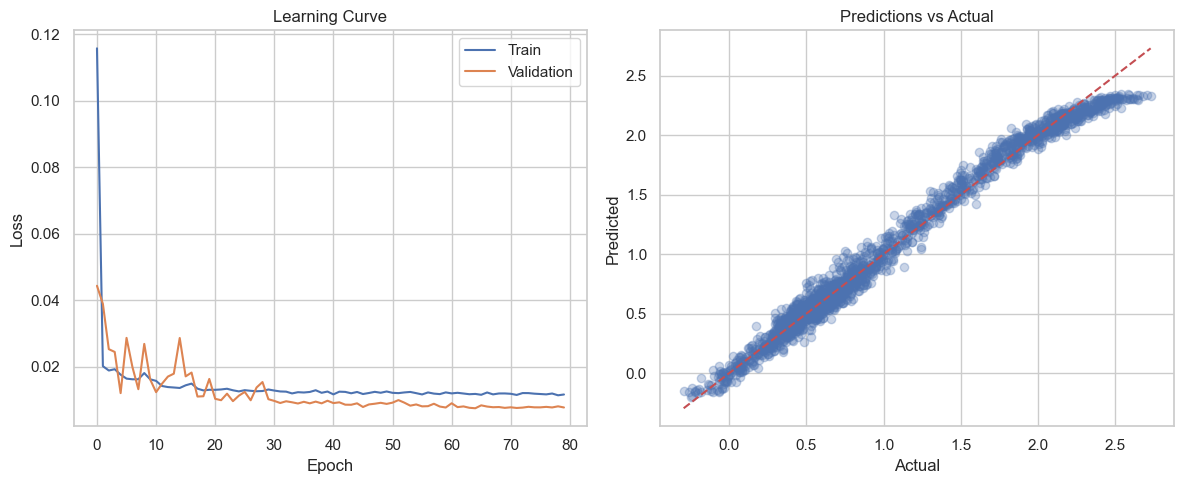

In [12]:
# Plot results
plt.figure(figsize=(12, 5))

# Plot learning curve
plt.subplot(1, 2, 1)
plt.plot(train_losses)
plt.plot(val_losses)
plt.title('Learning Curve')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend(['Train', 'Validation'])

# Plot predictions vs actual
plt.subplot(1, 2, 2)
plt.scatter(y_test, y_pred, alpha=0.3)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--')
plt.title('Predictions vs Actual')
plt.xlabel('Actual')
plt.ylabel('Predicted')

plt.tight_layout()
plt.show()
